# Primer 3 of 3: Visualization with seaborn

**DSC 210 Foundations of Data Science**

*A multi-day primer (~2 class days). Adapts a colleague's matplotlib notebook and material from Huber (CC BY-NC-SA 4.0). Uses Palmer Penguins (CC0), Anscombe's Quartet, and Gapminder-style data.*

## How to use this notebook (instructor)

Same three roles as Primers 1-2: **RUN-TOGETHER**, **FILL-IN-LIVE** (`# together:`), and **PREDICT / DISCUSS**. Because plots are visual, the predict-then-run beats here often ask students to **sketch the plot they expect** before you reveal it. Two days; each ends with an activity. Hide this cell in a student copy.

## Where we are

```
ASK  ->  GET  ->  [ EXPLORE ]  ->  MODEL  ->  COMMUNICATE
```

This is the heart of EXPLORE, and it also serves COMMUNICATE. We have summarized data as single numbers; now we **see** it. The central lesson of this primer: a plot is not decoration added at the end, it is how you *ask questions* of data and how you *find* what a table of numbers hides.

## What you will be able to do

1. Explain why summary statistics alone can mislead, and why we always plot.
2. Build the three workhorse plots with seaborn: **histogram**, **boxplot**, **scatterplot**.
3. Add a categorical dimension with `hue`.
4. Label and title a figure (a little matplotlib underneath seaborn).
5. Read a plot critically: shape, spread, outliers, relationships.
6. Choose an appropriate plot for a question.

## Why seaborn?

Python's foundational plotting library is **matplotlib**. It is powerful but verbose. **seaborn** is built on top of it and produces statistical plots from tidy data in *one line*, which is exactly what a sophomore data course needs. We use seaborn to make the plot and borrow a few matplotlib commands (`plt.title`, `plt.xlabel`) to label it. The standard imports:

In [5]:
# RUN-TOGETHER
import seaborn as sns
import matplotlib.pyplot as plt

penguins = sns.load_dataset('penguins')
penguins.head(3)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female


---

# Day 1: Why We Plot, and Seeing One Variable

---

## 1.1 The motivating hook: when numbers lie

Before any plotting syntax, a demonstration of *why* we plot at all. We load **Anscombe's Quartet**: four small datasets. Using your Primer 2 NumPy skills, we first compute their summary statistics.

In [6]:
# RUN-TOGETHER
import numpy as np
anscombe = sns.load_dataset('anscombe')

# Compute mean of x, mean of y, and correlation for each of the four sets.
for name, group in anscombe.groupby('dataset'):
    mx = group['x'].mean()
    my = group['y'].mean()
    r = np.corrcoef(group['x'], group['y'])[0, 1]
    print(f'Set {name}:  mean x = {mx:.2f}, mean y = {my:.2f}, r = {r:.2f}')

Set I:  mean x = 9.00, mean y = 7.50, r = 0.82
Set II:  mean x = 9.00, mean y = 7.50, r = 0.82
Set III:  mean x = 9.00, mean y = 7.50, r = 0.82
Set IV:  mean x = 9.00, mean y = 7.50, r = 0.82


> **Predict, then reveal.** Every one of the four datasets has essentially the **same** mean x, mean y, and correlation. So, predict: do the four datasets *look* the same? Sketch what you expect on paper, then we plot them.

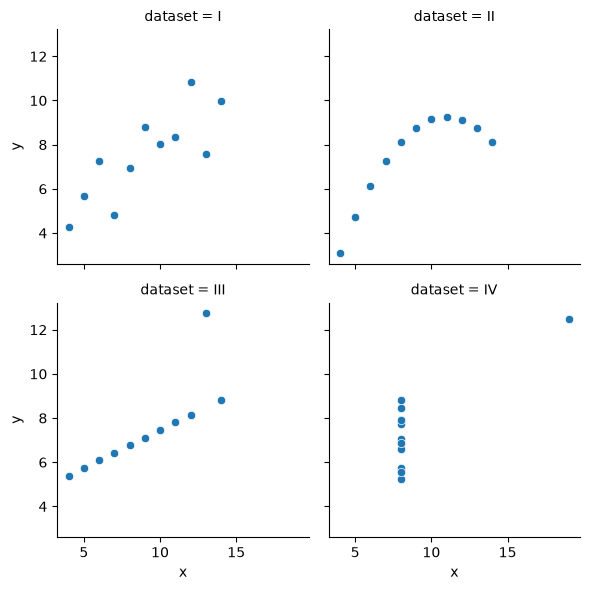

In [7]:
# RUN-TOGETHER: the reveal
sns.relplot(data=anscombe, x='x', y='y', col='dataset',
            col_wrap=2, height=3)
plt.show()

Identical statistics, four completely different stories: one clean line, one curve, one line dragged by a single outlier, one vertical stack. **This is the whole reason we plot.** A summary compresses; a plot reveals. Never trust `describe()` output without looking. (This is the same lesson as the Datasaurus Dozen, if you have seen it, and it echoes Anscombe from your statistics course.)

## 1.2 Seeing one variable: the histogram

A **histogram** shows the distribution of one numeric variable: it bins the values and shows how many fall in each bin. This is how you see shape, center, spread, and skew at a glance. One line in seaborn:

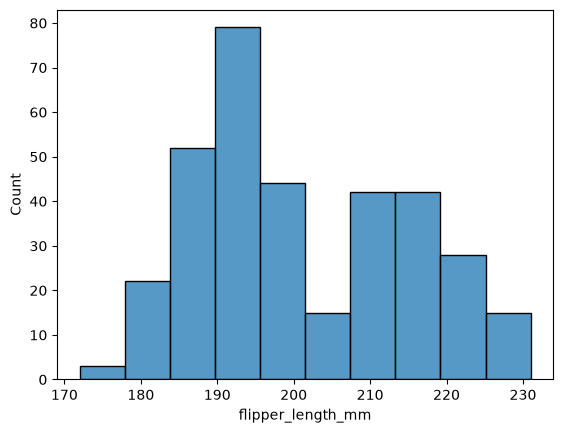

In [8]:
# RUN-TOGETHER
sns.histplot(data=penguins, x='flipper_length_mm')
plt.show()

> **Predict, then run.** That histogram looked a little lumpy, maybe two bumps. We have three penguin species. Predict: if we color the bars by species, will the bumps separate out? Sketch your guess, then run.

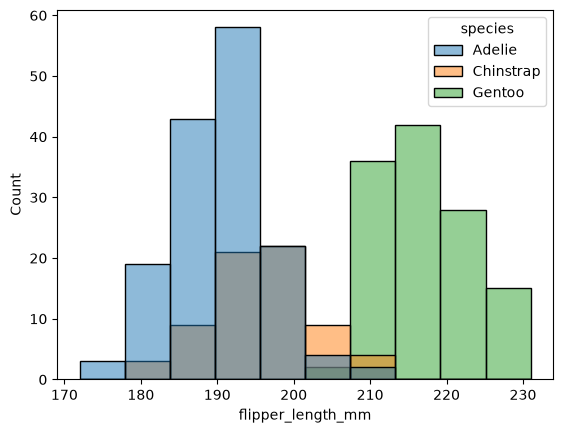

In [9]:
# FILL-IN-LIVE
# together: add a categorical split by filling in the hue column.
sns.histplot(data=penguins, x='flipper_length_mm', hue='species')
plt.show()
# The two bumps WERE the species. A hidden pattern, now visible.

> **Discuss.** The single-color histogram hid a real structure that the colored one revealed. What does this suggest about exploring a new dataset? What might you miss if you only ever computed one overall mean flipper length?

## 1.3 Comparing groups: the boxplot

A **boxplot** summarizes a distribution per category: the box spans the middle 50% of the data, the line inside is the median, and points beyond the whiskers are potential outliers. Perfect for comparing groups.

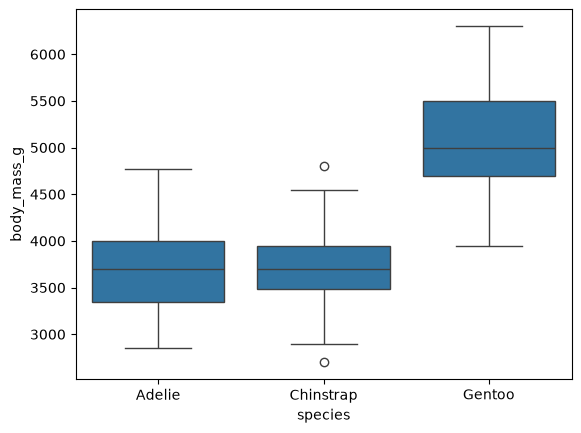

In [10]:
# RUN-TOGETHER
sns.boxplot(data=penguins, x='species', y='body_mass_g')
plt.show()

> **Predict, then run.** From the boxplot, which species looks heaviest, and which two look most similar? Now we add labels so the figure could stand on its own in a report.

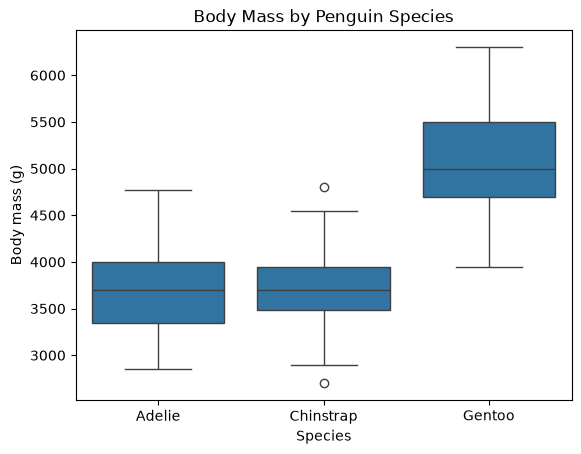

In [11]:
# FILL-IN-LIVE
sns.boxplot(data=penguins, x='species', y='body_mass_g')
# together: give the plot an informative title and axis labels.
plt.title('Body Mass by Penguin Species')   # <-- edit live
plt.xlabel('Species')
plt.ylabel('Body mass (g)')
plt.show()

## Day 1 activity: one-variable EDA (~15 min)

> **Small-group build.** Pick a different numeric feature (`bill_length_mm` or `bill_depth_mm`) and explore it. Fill in the blanks; predict the shape before each plot.

In [12]:
# Group build (fill in the ____)
feature = 'bill_length_mm'    # try bill_depth_mm too

# (1) Histogram of the feature, split by species.
sns.histplot(data=penguins, x=feature, hue=____)   # fill in
plt.title('Distribution of ' + feature)
plt.show()

# (2) Boxplot of the feature across species.
sns.boxplot(data=penguins, x='species', y=____)     # fill in
plt.show()

NameError: name '____' is not defined

> **Discuss to close Day 1.** Did your feature separate the species as cleanly as flipper length did? Some features distinguish groups well and others do not, that difference is exactly what makes a feature useful for prediction later in the course.

---

# Day 2: Relationships, Log Scales, and Critique

---

## 2.1 Two variables: the scatterplot

A **scatterplot** shows the relationship between two numeric variables, one point per case. This is where you see correlation with your eyes (recall the r = 0.87 we computed for mass vs. flipper length in Primer 2).

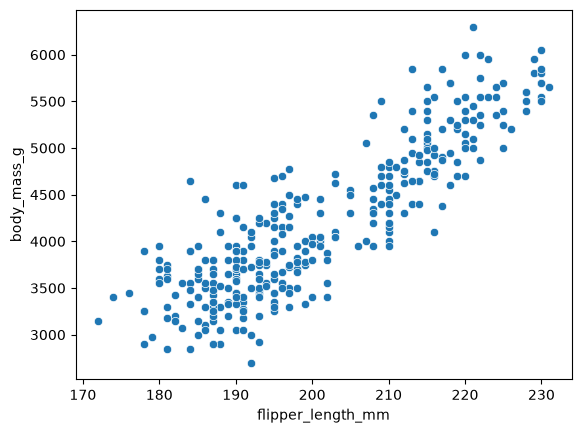

In [13]:
# RUN-TOGETHER
sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g')
plt.show()

> **Predict, then run.** We know these two variables are strongly correlated overall. Predict: if we color by species, will we see one big cloud, or separate clusters? Sketch it, then run.

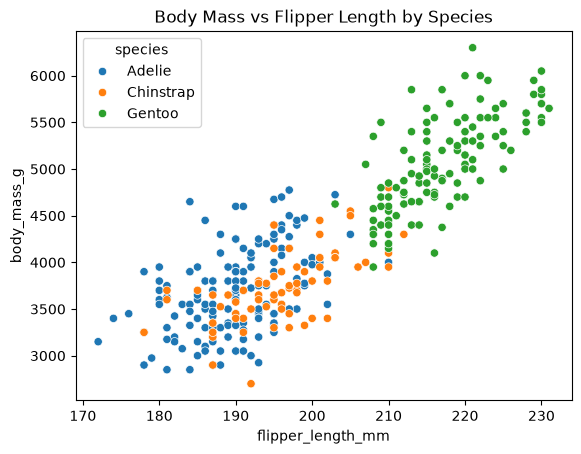

In [14]:
# FILL-IN-LIVE
# together: color the points by species to reveal structure.
sns.scatterplot(data=penguins, x='flipper_length_mm',
                y='body_mass_g', hue='species')   # <-- fill hue live
plt.title('Body Mass vs Flipper Length by Species')
plt.show()

> **Discuss.** The overall trend is real, but each species also forms its own cluster. This is a preview of a deep idea: a pattern in the whole dataset can look different once you account for groups. (Statistics students: this is the flavor of Simpson's paradox.)

## 2.2 See it all at once: the pairplot

When you meet a new dataset, `pairplot` draws every numeric variable against every other, with histograms on the diagonal. It is the fastest way to get oriented. One line, a lot of insight.

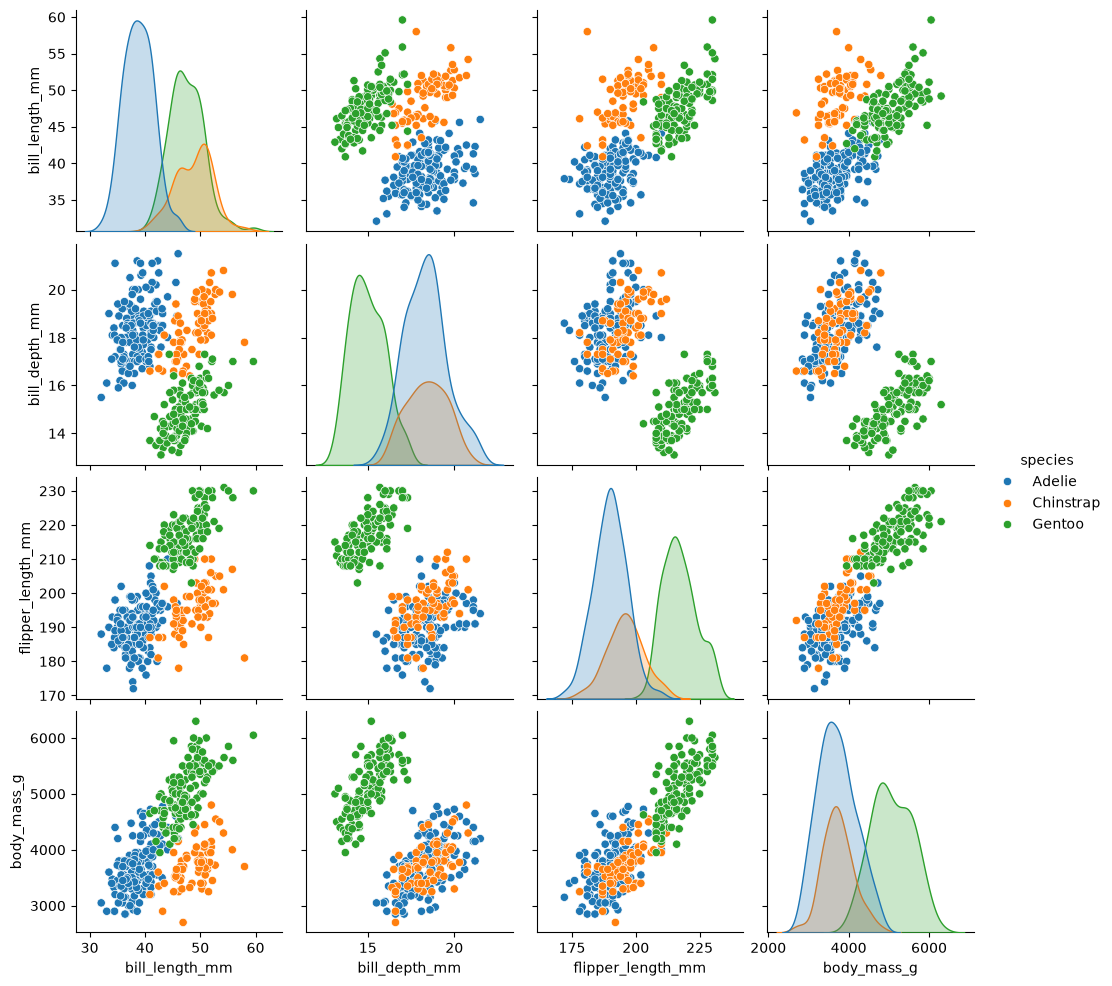

In [15]:
# RUN-TOGETHER (this one takes a moment to draw)
sns.pairplot(penguins, hue='species')
plt.show()

> **Discuss.** Scanning the pairplot, which *pair* of measurements separates the three species most cleanly? If you had to pick just two features to tell the species apart, which would you choose, and how can you tell from these plots?

## 2.3 When a plot needs a log scale (Gapminder)

Sometimes a raw scatterplot is unreadable because the data spans huge ranges. A classic case: national income (GDP per capita) vs. life expectancy. We use a small Gapminder-style sample. First the raw plot, then the fix.

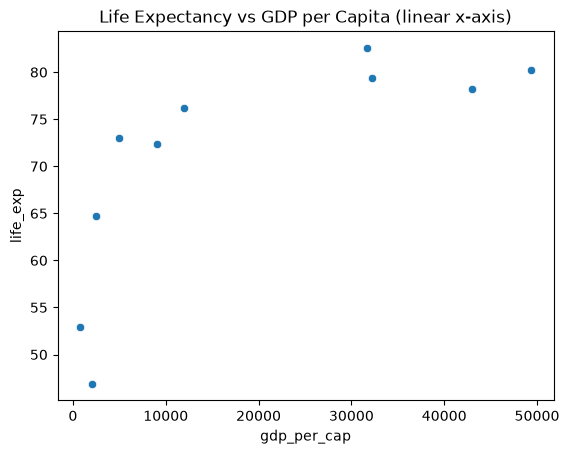

In [16]:
# RUN-TOGETHER
# A small illustrative sample (a few countries, 2007-style figures).
import pandas as pd
gap = pd.DataFrame({
    'country': ['Ethiopia','India','China','Brazil','Mexico',
                'Germany','Japan','USA','Norway','Nigeria'],
    'gdp_per_cap': [780, 2452, 4959, 9066, 11978,
                    32170, 31656, 42952, 49357, 2014],
    'life_exp': [52.9, 64.7, 73.0, 72.4, 76.2,
                 79.4, 82.6, 78.2, 80.2, 46.9],
})
sns.scatterplot(data=gap, x='gdp_per_cap', y='life_exp')
plt.title('Life Expectancy vs GDP per Capita (linear x-axis)')
plt.show()

> **Predict, then run.** On the linear axis, the poorer countries are all squashed against the left edge, hard to distinguish. A **log scale** on the x-axis spreads them out. Predict how the shape changes, then run.

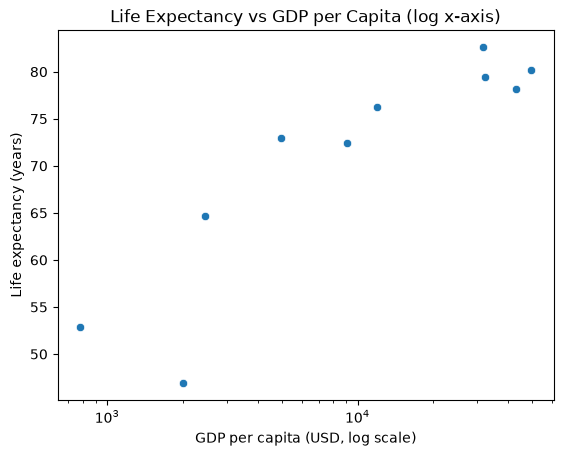

In [17]:
# FILL-IN-LIVE
sns.scatterplot(data=gap, x='gdp_per_cap', y='life_exp')
# together: switch the x-axis to a logarithmic scale.
plt.xscale('log')     # <-- add/remove this line live to compare
plt.title('Life Expectancy vs GDP per Capita (log x-axis)')
plt.xlabel('GDP per capita (USD, log scale)')
plt.ylabel('Life expectancy (years)')
plt.show()

On the log axis the relationship becomes clear and roughly linear: each *multiplication* of income buys a similar gain in life expectancy, up to a point. **The scale you choose is part of the story you tell**, which is exactly why the next section is about honesty.

## 2.4 Plots can mislead: a critique studio

Because a plot tells a story, a careless or dishonest plot tells a false one. The most common trick is a truncated y-axis that exaggerates a difference. We build the same data two ways.

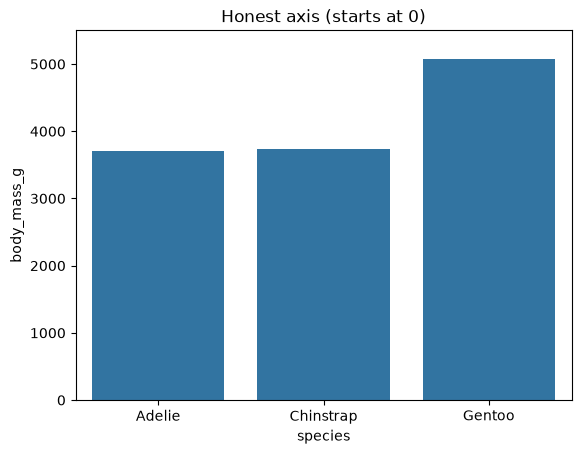

In [18]:
# RUN-TOGETHER
means = penguins.groupby('species')['body_mass_g'].mean().reset_index()

# HONEST: y-axis starts at 0
sns.barplot(data=means, x='species', y='body_mass_g')
plt.ylim(0, 5500)
plt.title('Honest axis (starts at 0)')
plt.show()

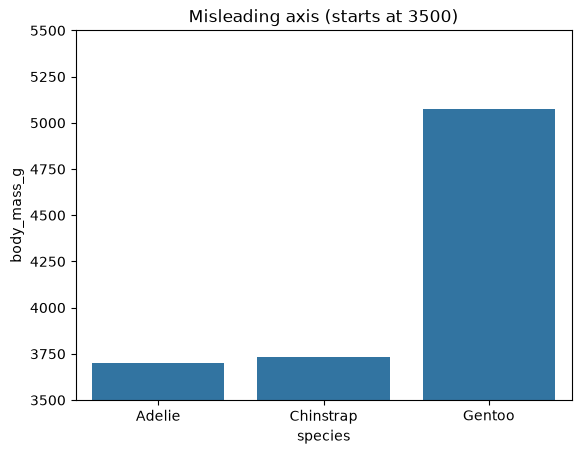

In [19]:
# RUN-TOGETHER
# MISLEADING: y-axis starts at 3500, exaggerating the gaps
sns.barplot(data=means, x='species', y='body_mass_g')
plt.ylim(3500, 5500)
plt.title('Misleading axis (starts at 3500)')
plt.show()

> **Think-pair-share (critique).** The two charts show the *identical* data. Describe how the second one changes the impression a casual reader gets. When might starting an axis above zero be legitimate, and when is it deceptive? Who bears responsibility for how a chart is read, the maker or the viewer?

## Primer 3 capstone activity: a one-question EDA (~20 min)

> **Small-group investigation.** Choose ONE question about the penguins you find interesting, for example: *Do the sexes differ in body mass within a species? Which island has the heaviest penguins? Which two measurements best separate the species?* Then produce the **single plot** that best answers it, fully labeled, and write your finding.

Starter scaffold below; adapt it to your question.

In [ ]:
# Capstone: your one-question EDA (edit freely)
import seaborn as sns, matplotlib.pyplot as plt
penguins = sns.load_dataset('penguins')

# Example scaffold: body mass by species, split by sex.
sns.boxplot(data=penguins, x='species', y='body_mass_g', hue='sex')
plt.title('...write an informative title...')
plt.xlabel('...')
plt.ylabel('...')
plt.show()

# Our question:
# Our finding (one or two sentences):


> **Gallery walk and reflect.** Groups display their plots; the class reads each one *cold* and says what it thinks the finding is before the authors explain. A plot that communicates well needs little explanation, that is the standard we are aiming for. This capstone is a rehearsal for the EDA reports you will write in the rest of the course.

## Primer 3 summary

- Summary statistics compress and can mislead (**Anscombe**); always plot.
- **Histogram** shows one variable's distribution; **boxplot** compares groups; **scatterplot** shows a relationship; **pairplot** surveys everything.
- `hue=` adds a categorical dimension and often reveals hidden structure.
- seaborn makes the plot in one line; matplotlib (`plt.title`, `plt.xlabel`, `plt.xscale`) labels and adjusts it.
- The **scale and axis choices are part of the story**; make honest plots and read others' plots critically.

**Primer complete.** You now have Python, NumPy, and visualization, the toolkit for the EXPLORE stage. Next we bring in **pandas** and turn these skills loose on full datasets.

## References

- Huber, F. *Hands-on Introduction to Data Science with Python*. https://florian-huber.github.io/data_science_course/
- seaborn documentation and gallery: https://seaborn.pydata.org/
- Wilke, C. *Fundamentals of Data Visualization* (free): https://clauswilke.com/dataviz/
- Anscombe, F. J. (1973). *Graphs in Statistical Analysis*. The American Statistician, 27(1), 17-21.
- Gapminder / Our World in Data for the income vs. life expectancy framing: https://ourworldindata.org/ (figures above are illustrative; verify before quoting specific numbers).